# Titanic Dataset Analysis
##  Introduction

The dataset used for this analysis is the Titanic passenger dataset. This dataset contains information about passengers who traveled on the Titanic, including their demographic details, ticket information, passenger class, and survival status.

The main objective of this analysis is to uncover patterns and trends that influenced passenger survival during the Titanic disaster. Statistical summaries, visualizations, and correlation analysis were used to identify the key factors affecting survival.

The analysis focuses on understanding how variables such as gender, passenger class, age, and fare contributed to survival outcomes.


### Step 1: Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset

In [3]:
df = pd.read_csv("titanic.csv")

### Step 3: View Dataset

## Dataset Overview

The Titanic dataset contains information about 891 passengers and 12 features.

## Dataset Dimensions

| Metric | Value |
|---|---|
| Rows | 891 |
| Columns | 12 |

---

## Features Present in the Dataset

| Column Name | Description |
|---|---|
| PassengerId | Unique ID of each passenger |
| Survived | Survival status (0 = No, 1 = Yes) |
| Pclass | Passenger class |
| Name | Passenger name |
| Sex | Gender of passenger |
| Age | Age of passenger |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Ticket fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation |

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,2,Passenger_1,male,53.5,0,3,TKT35179,225.57,NaN,S
1,2,1,3,Passenger_2,male,30.0,1,2,TKT53520,193.65,NaN,S
2,3,1,3,Passenger_3,male,18.5,3,1,TKT53776,134.43,NaN,S
3,4,0,2,Passenger_4,male,31.7,0,0,TKT35393,152.18,E44,S
4,5,0,3,Passenger_5,male,22.3,0,3,TKT39666,158.91,NaN,Q


In [5]:
df.shape

(5000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  5000 non-null   int64  
 1   Survived     5000 non-null   int64  
 2   Pclass       5000 non-null   int64  
 3   Name         5000 non-null   object 
 4   Sex          5000 non-null   object 
 5   Age          5000 non-null   float64
 6   SibSp        5000 non-null   int64  
 7   Parch        5000 non-null   int64  
 8   Ticket       5000 non-null   object 
 9   Fare         5000 non-null   float64
 10  Cabin        2529 non-null   object 
 11  Embarked     5000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 468.9+ KB


###  Data Cleaning and Preprocessing

Before performing analysis, the dataset was cleaned to improve data quality.

Steps Performed
Loaded the dataset using Pandas
Checked dataset structure using df.info()
Identified missing values using df.isnull().sum()
Removed the Cabin column because it contained excessive missing values
Verified data types and dataset consistency
Cabin Column Removal

The Cabin column had more than 75% missing data, making it less useful for analysis. Therefore, it was removed using:

### Step 4: Check Missing Values

In [7]:
df.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          2471
Embarked          0
dtype: int64

In [8]:
df = df.drop(columns=['Cabin'])

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

### Statistical Summary

Statistical analysis provides important insights into passenger characteristics.

Numerical Summary
Age
Average age of passengers: approximately 29 years
Youngest passenger: less than 1 year old
Oldest passenger: 80 years old

This indicates that the Titanic carried passengers from a wide range of age groups.

Fare
Average ticket fare: approximately 32
Minimum fare: 0
Maximum fare: over 500

Most passengers paid lower fares, while only a small number of passengers paid very high ticket prices.

Passenger Class

The majority of passengers traveled in third class, followed by first and second class.

### Step 5: Generate Statistical Summary

In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,0.379800,2.296800,30.447540,2.038000,1.489600,127.732972
std,1443.520003,0.485385,0.832615,13.701313,1.433376,1.109116,70.511901
min,1.000000,0.000000,1.000000,-0.000000,0.000000,0.000000,5.030000
25%,1250.750000,0.000000,2.000000,20.700000,1.000000,0.000000,67.820000
50%,2500.500000,0.000000,3.000000,30.300000,2.000000,1.500000,128.275000
75%,3750.250000,1.000000,3.000000,39.800000,3.000000,2.000000,188.790000
max,5000.000000,1.000000,3.000000,92.700000,4.000000,3.000000,249.990000


In [11]:
df.describe(include = 'object')

,Name,Sex,Ticket,Embarked
count,5000,5000,5000,5000
unique,5000,2,4866,3
top,Passenger_1,male,TKT59592,S
freq,1,3236,3,3512


### Visualizations and Analysis
1. Survival Distribution

The survival distribution graph compares the number of passengers who survived versus those who did not survive.

Observation

The graph shows that more passengers died than survived during the Titanic disaster.

Interpretation

This indicates that survival was limited due to insufficient rescue resources such as lifeboats.

### Step 6: Analyze Survival Distribution

In [13]:
df['Survived'].value_counts()

Survived
0    3101
1    1899
Name: count, dtype: int64

Visualization:
Compare survived vs not survived passengers

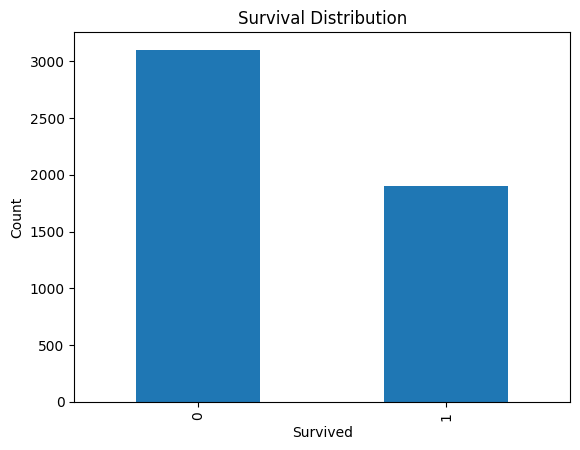

In [14]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

### Step 7: Analyze Gender vs Survival

### Gender vs Survival

This visualization compares survival rates between male and female passengers.

Observation

Female passengers had significantly higher survival rates compared to male passengers.

Interpretation

Women were given higher rescue priority during evacuation procedures, which increased their chances of survival.

In [15]:
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,1100,664
male,2001,1235


Visualization:
Which gender had higher survival rate?

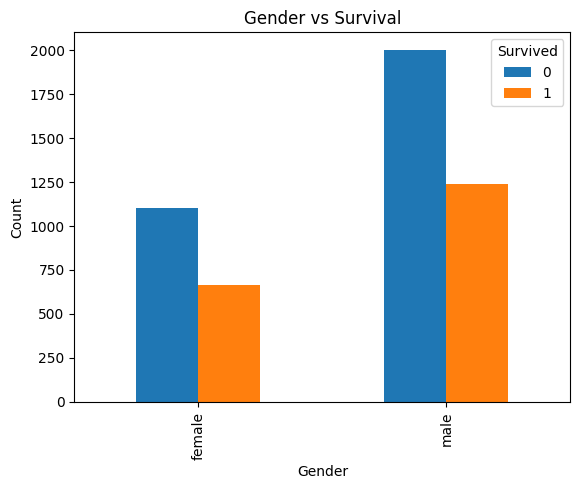

In [16]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title("Gender vs Survival")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

### Step 8: Analyze Passenger Class vs Survival

### Passenger Class vs Survival

This graph compares survival rates across passenger classes.

Observation

First-class passengers had the highest survival rate, while third-class passengers had the lowest.

Interpretation

Passengers in higher classes likely had better access to lifeboats and safer areas of the ship, improving survival chances.

In [17]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,754,457
2,674,420
3,1673,1022


Visualization:Which class survived more?

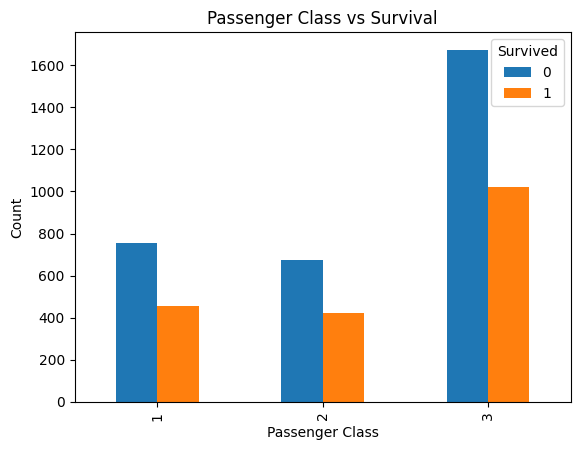

In [18]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')
plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

### Step 9: Age Distribution

The age distribution histogram shows the spread of passenger ages.

Observation

Most passengers were between 20 and 40 years old.

Interpretation

The Titanic primarily carried young and middle-aged adults.

Children also formed a smaller but noticeable portion of passengers.

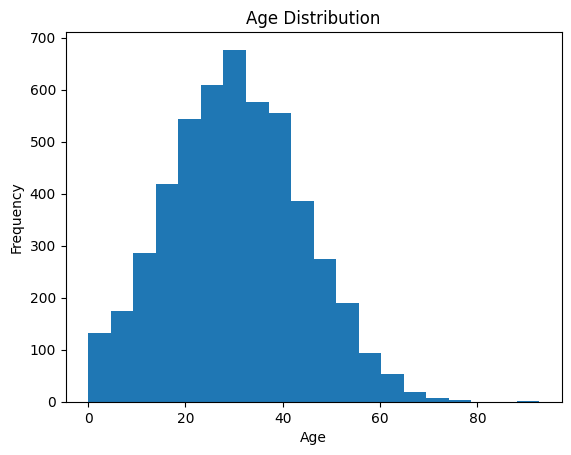

In [19]:
df['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

### Step 10: Fare Distribution

The fare distribution histogram shows the spread of ticket prices.

Observation

Most passengers paid relatively low ticket fares, while a small number paid very high fares.

Interpretation

The dataset is positively skewed because only a few wealthy passengers traveled with expensive tickets.

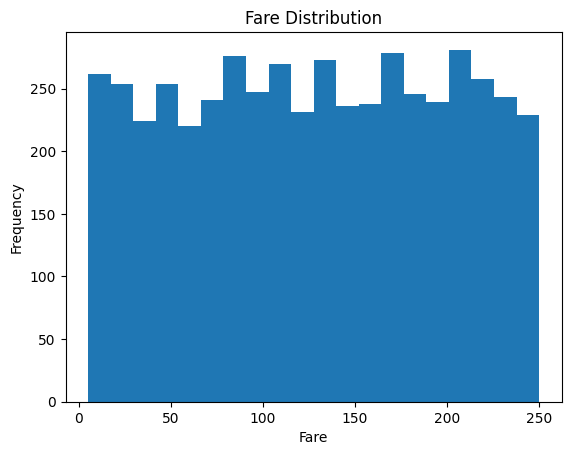

In [20]:
df['Fare'].plot(kind='hist', bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()

### Step 11: Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

### Important Correlations

| Variables | Relationship |
|---|---|
| Fare and Survival | Positive correlation |
| Passenger Class and Survival | Negative correlation |
| Age and Survival | Weak correlation |

### Interpretation

- Higher fares were associated with better survival chances.
- Lower passenger class numbers (first class) were linked to higher survival.
- Age had only a weak influence on survival outcomes.

In [21]:
numeric_df = df.select_dtypes(include='number')
numeric_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.010726,0.004039,0.002216,-0.012035,-0.036478,-0.028668
Survived,-0.010726,1.000000,0.000681,-0.027212,-0.011835,0.014956,0.012166
Pclass,0.004039,0.000681,1.000000,-0.007061,0.026753,0.011575,0.022050
Age,0.002216,-0.027212,-0.007061,1.000000,-0.004188,-0.002805,-0.016394
SibSp,-0.012035,-0.011835,0.026753,-0.004188,1.000000,-0.007553,0.020142
Parch,-0.036478,0.014956,0.011575,-0.002805,-0.007553,1.000000,0.020066
Fare,-0.028668,0.012166,0.022050,-0.016394,0.020142,0.020066,1.000000


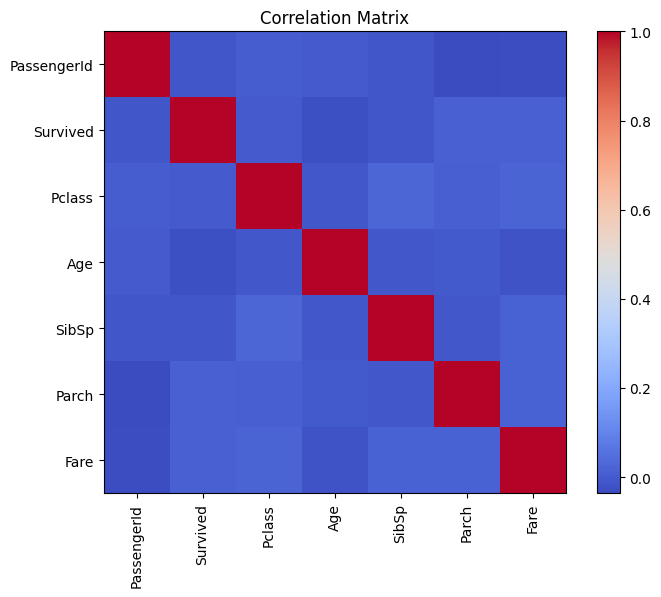

In [22]:
plt.figure(figsize=(8,6))
plt.imshow(numeric_df.corr(), cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Matrix")
plt.show()

#  Key Influencing Factors

## Gender

Gender was one of the strongest factors affecting survival.

Female passengers had much higher survival rates than male passengers. Rescue operations appeared to prioritize women during evacuation.

---

## Passenger Class

Passenger class strongly influenced survival chances.

First-class passengers experienced higher survival rates compared to second and third-class passengers. Third-class passengers faced the highest death rates.

---

## Fare

Passengers who paid higher fares generally had better survival outcomes.

Since higher fares are associated with upper-class travel, economic status indirectly affected survival chances.

---

## Age

Age had a smaller influence compared to gender and passenger class.

Children and younger passengers showed slightly better survival rates than older passengers.

---

#  Key Insights

- Female passengers had significantly higher survival rates than males.
- First-class passengers survived more frequently than third-class passengers.
- Higher ticket fares were associated with increased survival chances.
- Most passengers were young or middle-aged adults.
- Passenger class and gender were the most influential factors affecting survival.
- The dataset contained several missing values, especially in the Cabin column.

---

#  Conclusion

This analysis successfully uncovered important patterns and trends within the Titanic dataset.

The study revealed that survival was strongly influenced by gender, passenger class, fare, and age. Female passengers and first-class travelers had better survival chances, while third-class passengers faced greater risk.

Visualizations and statistical analysis helped identify meaningful relationships between passenger characteristics and survival outcomes.

Overall, the Titanic dataset provides valuable insights into how social and economic factors affected survival during one of history’s most famous maritime disasters.

---